Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260724_1336_to_20260724_1354_Q.npz


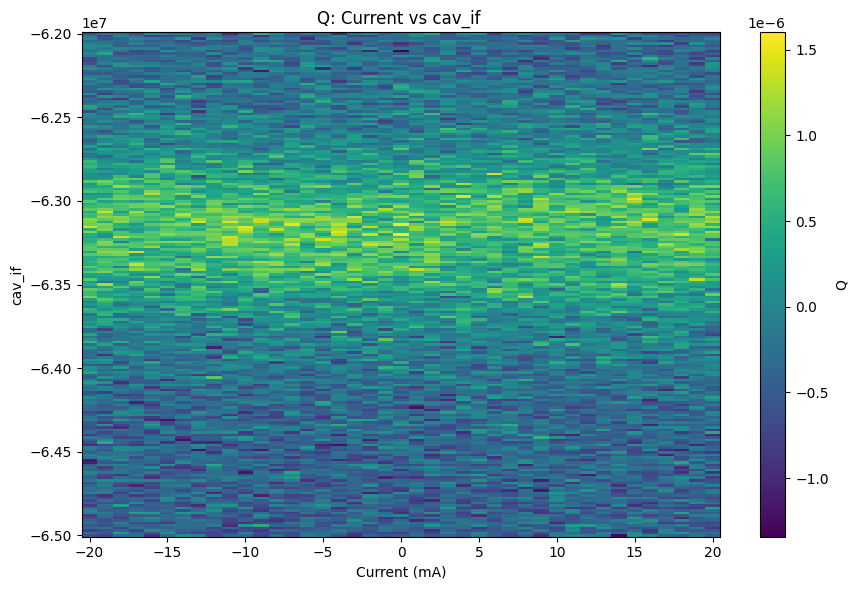

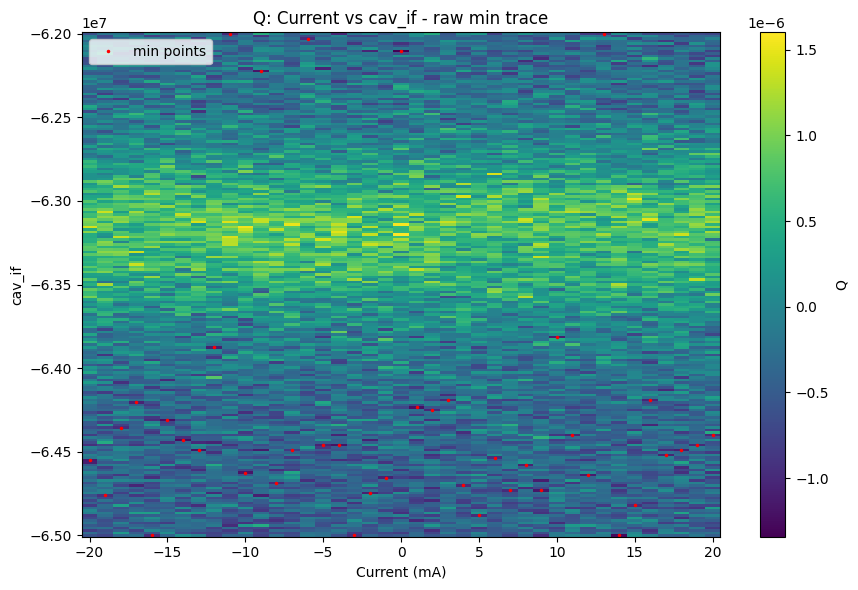

In [24]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
current_A_print =np.linspace(start=-20e-3, stop=20e-3, num=41)
batches = [
    {
        "date": "2026-07-24",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-08",
        "time": ((13, 36), (13, 54)),
        "current": current_A_print#[0:104]#np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    # {
    #     "date": "2026-07-05",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "time": ((0, 0), (6, 0)),
    #     "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    # },
]

file_key = "CavitySpec_versus_flux"
plot_data = "Q"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

#     # Step 6: Filter Range
#     mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
#     x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

#     # Step 7: Clean Vectorized Outliers (No loop needed!)
#     good_mask = np.ones_like(y_sel, dtype=bool)
#     if remove_outliers and len(y_sel) > 2:
#         jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
#         jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
#         good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

#     x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

#     # Step 8: Plot Profile Verification
#     plt.figure(figsize=(8, 4))
#     plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
#     plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
#     plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
#     plt.title(f"Cleaned {find_mode} trace, {plot_data}")
#     plt.tight_layout()
#     plt.show()

#     # Step 9: Cleaned 2D Focus Plot
#     base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
#     plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
#     plt.xlim(current_min_mA, current_max_mA)
#     plt.legend()
#     plt.show()

#     # Step 10: Save Cleaned Data
#     if save_min_trace:
#         save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
#         np.savez_compressed(
#             os.path.join(output_folder, save_min_name),
#             current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
#             good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
#         )

#     # Step 11: Final Printout
#     print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
#     print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

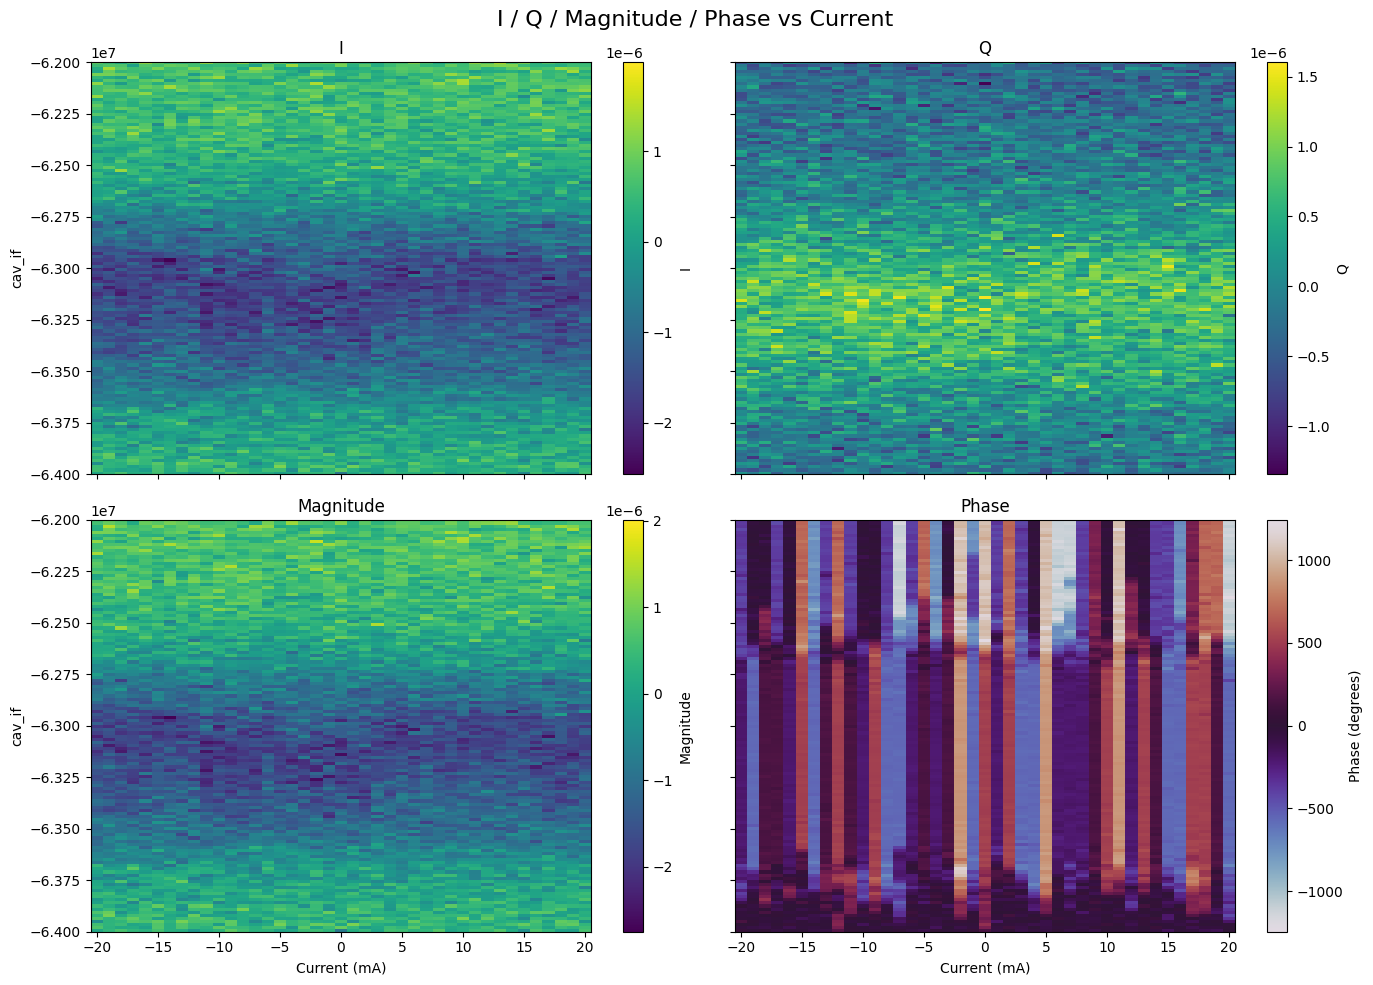

In [26]:
if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = (
        data["cav_if"]
        if "cav_if" in data.keys()
        else data["y_values"]
    )

    I_2d = np.array(data["I"])
    Q_2d = np.array(data["Q"])
    MAG_2d = np.array(data["MAG"])

    # ==========================================================
    # Calculate phase
    # ==========================================================

    # Phase in radians
    PHASE_2d = np.arctan2(Q_2d, I_2d)

    # Convert to degrees
    PHASE_2d_deg = np.degrees(PHASE_2d)

    # Optional: unwrap phase along frequency axis
    PHASE_2d_unwrapped = np.unwrap(
        PHASE_2d,
        axis=1
    )

    PHASE_2d_unwrapped_deg = np.degrees(
        PHASE_2d_unwrapped
    )

    # ==========================================================
    # Plot I, Q, MAG, PHASE
    # ==========================================================

    x_plot = (
        x_values * 1e3
        if plot_current_in_mA
        else x_values
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
        sharex=True,
        sharey=True
    )

    # ----------------------------------------------------------
    # I
    # ----------------------------------------------------------

    im0 = axes[0, 0].pcolormesh(
        x_plot,
        y_values,
        I_2d.T,
        shading="auto",
        cmap="viridis"
    )

    axes[0, 0].set_title("I")
    axes[0, 0].set_ylabel(y_label)

    fig.colorbar(
        im0,
        ax=axes[0, 0],
        label="I"
    )

    # ----------------------------------------------------------
    # Q
    # ----------------------------------------------------------

    im1 = axes[0, 1].pcolormesh(
        x_plot,
        y_values,
        Q_2d.T,
        shading="auto",
        cmap="viridis"
    )

    axes[0, 1].set_title("Q")

    fig.colorbar(
        im1,
        ax=axes[0, 1],
        label="Q"
    )

    # ----------------------------------------------------------
    # Magnitude
    # ----------------------------------------------------------

    im2 = axes[1, 0].pcolormesh(
        x_plot,
        y_values,
        MAG_2d.T,
        shading="auto",
        cmap="viridis"
    )

    axes[1, 0].set_title("Magnitude")
    axes[1, 0].set_xlabel(
        f"{x_label} "
        f"({'mA' if plot_current_in_mA else 'A'})"
    )
    axes[1, 0].set_ylabel(y_label)

    fig.colorbar(
        im2,
        ax=axes[1, 0],
        label="Magnitude"
    )

    # ----------------------------------------------------------
    # Phase
    # ----------------------------------------------------------

    im3 = axes[1, 1].pcolormesh(
        x_plot,
        y_values,
        PHASE_2d_unwrapped_deg.T,
        shading="auto",
        cmap="twilight"
    )

    axes[1, 1].set_title("Phase")
    axes[1, 1].set_xlabel(
        f"{x_label} "
        f"({'mA' if plot_current_in_mA else 'A'})"
    )

    fig.colorbar(
        im3,
        ax=axes[1, 1],
        label="Phase (degrees)"
    )

    # ==========================================================
    # Axis limits
    # ==========================================================

    # Current
    # axes[0, 0].set_xlim(
    #     current_min_mA,
    #     current_max_mA
    # )

    # Frequency
    axes[0, 0].set_ylim(
        -64e6,
        -62e6
    )

    # ==========================================================
    # Overall title
    # ==========================================================

    fig.suptitle(
        f"I / Q / Magnitude / Phase vs Current",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

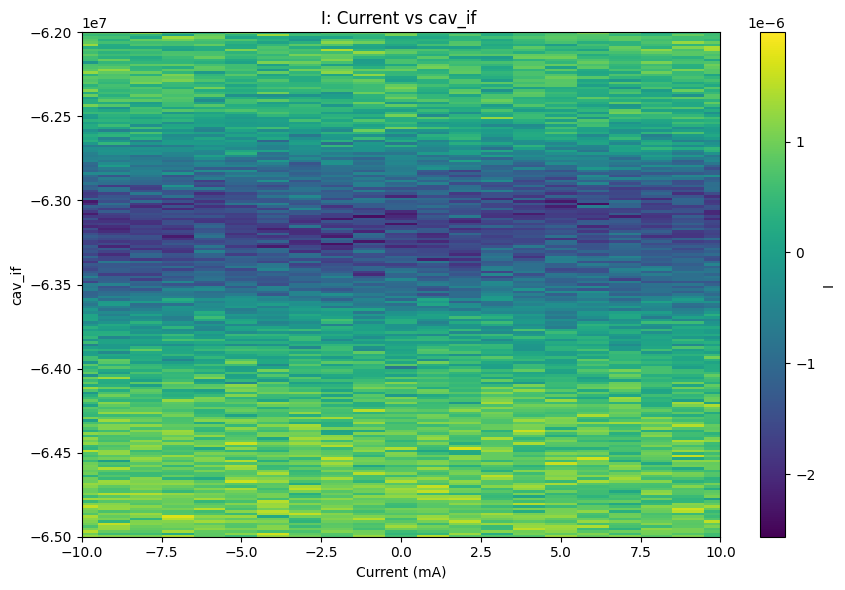

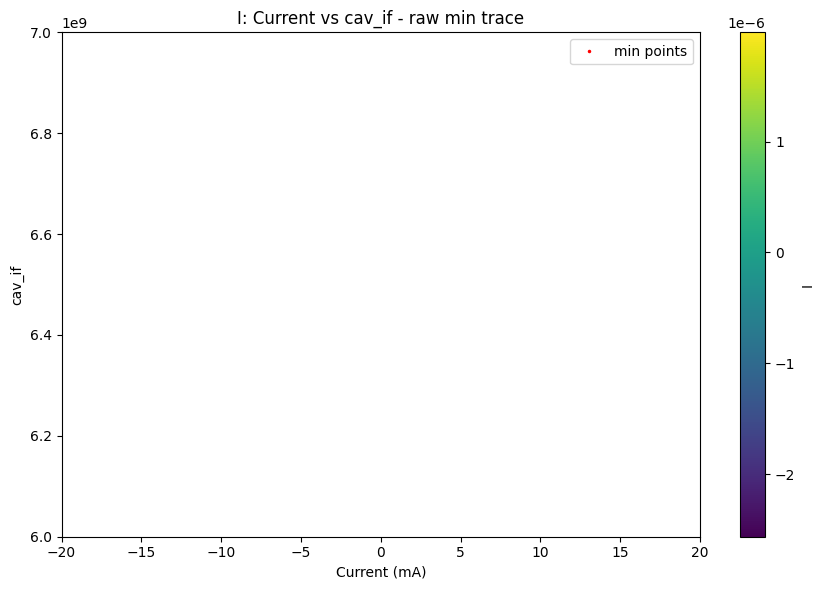

In [21]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)

    plt.xlim(-10, 10)       # x-axis: -20 to +20 mA
    plt.ylim(-65e6, -62e6)  # y-axis: 6 to 7 GHz

    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y = y_values[idx]
    trace_val = data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")

    plt.plot(
        x_values * 1e3 if plot_current_in_mA else x_values,
        trace_y,
        "r.",
        markersize=3,
        label=f"{find_mode} points"
    )

    plt.xlim(-20, 20)
    plt.ylim(6.0e9, 7.0e9)

    plt.legend()
    plt.show()

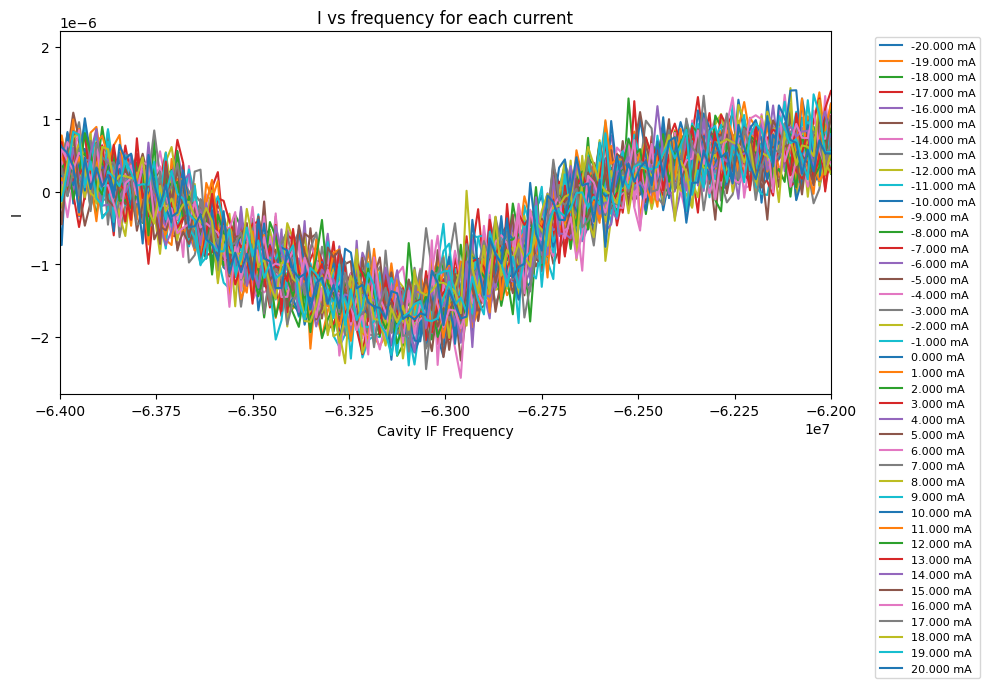

In [22]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Convert current to mA for labels
    currents_mA = x_values * 1e3

    # Plot 1D trace for each current
    plt.figure(figsize=(10, 6))

    for i, current in enumerate(currents_mA):
        plt.plot(
            y_values,
            data_2d[i, :],
            label=f"{current:.3f} mA"
        )

    plt.xlabel("Cavity IF Frequency")
    plt.ylabel(plot_data)
    plt.title(f"{plot_data} vs frequency for each current")

    # Optional limits
    plt.xlim(-64e6, -62e6)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

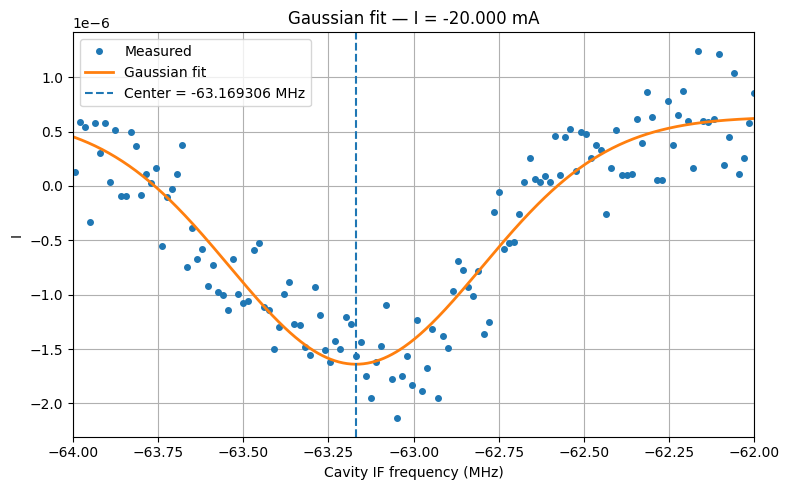

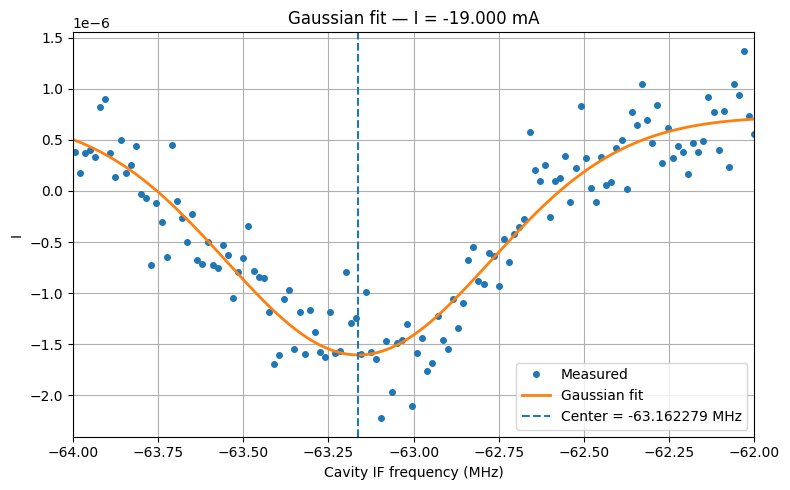

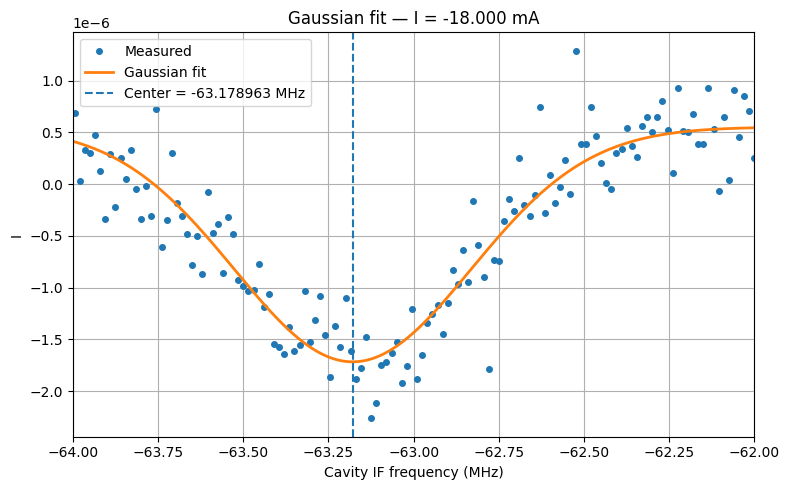

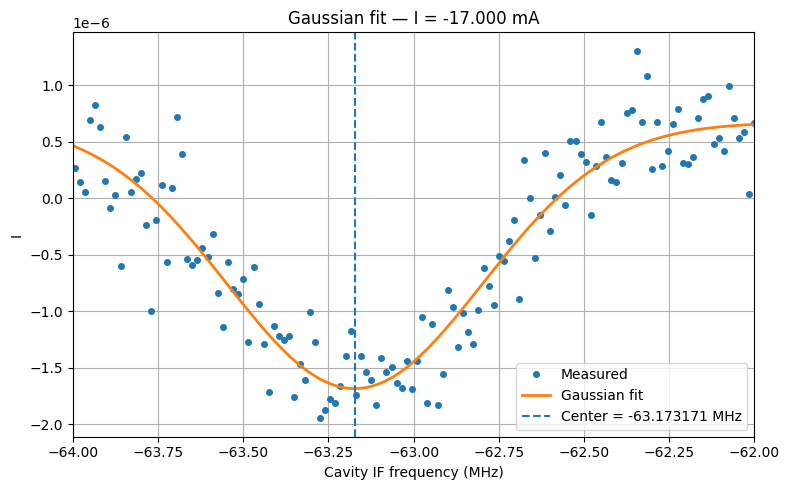

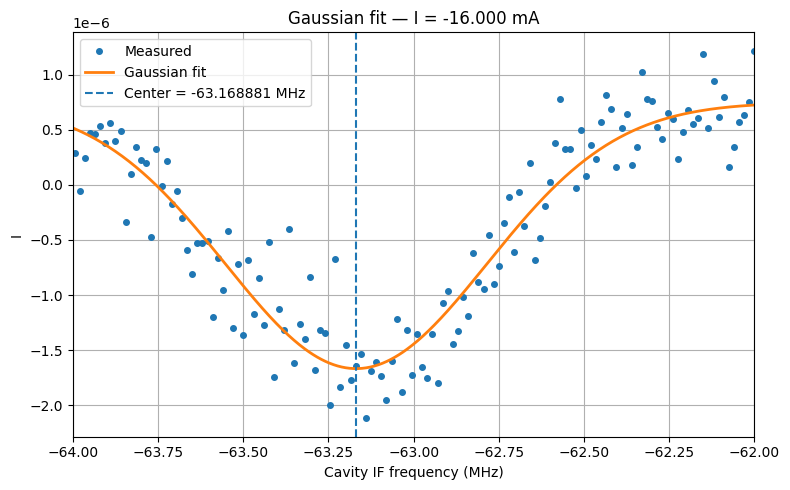

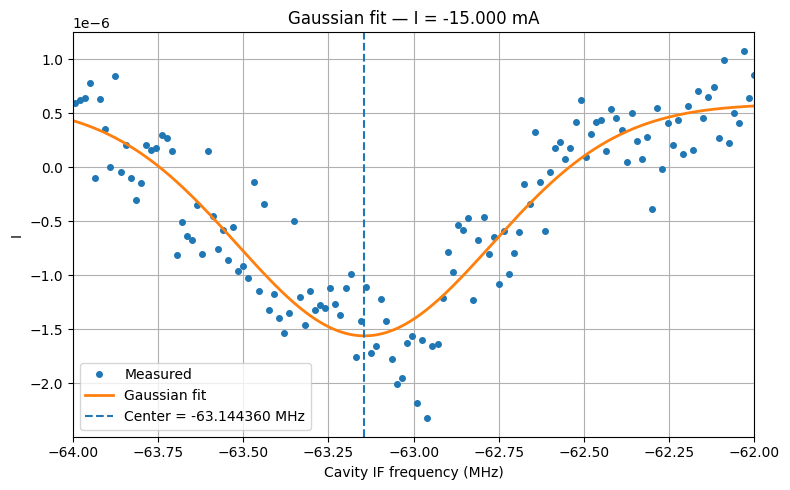

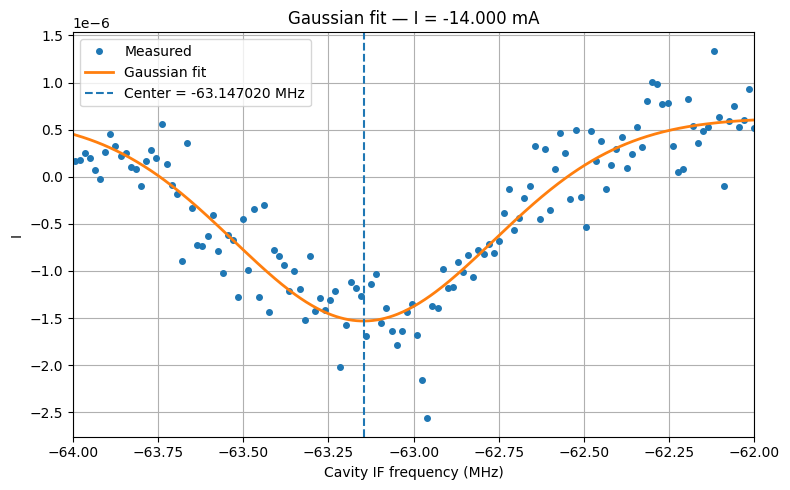

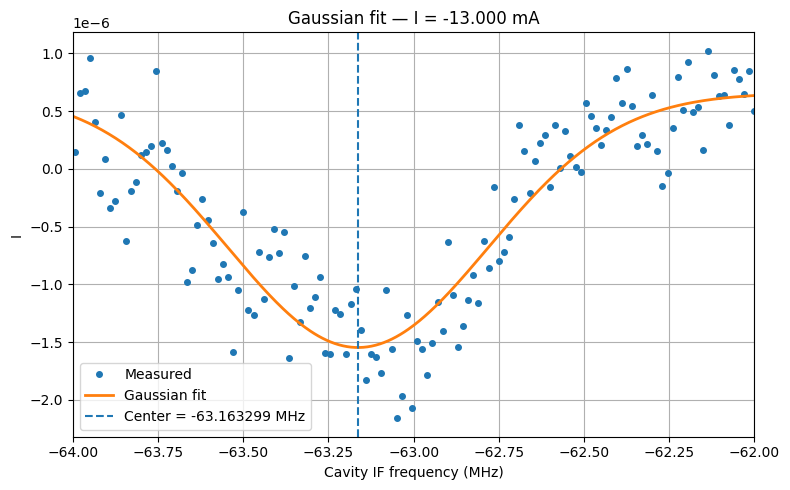

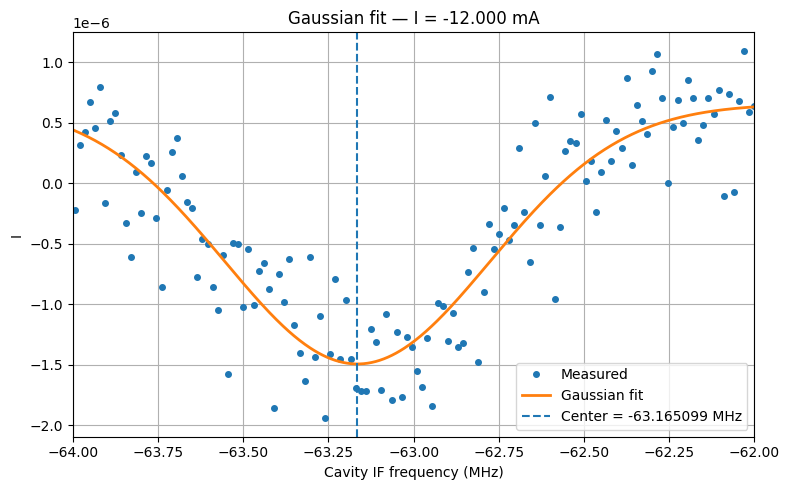

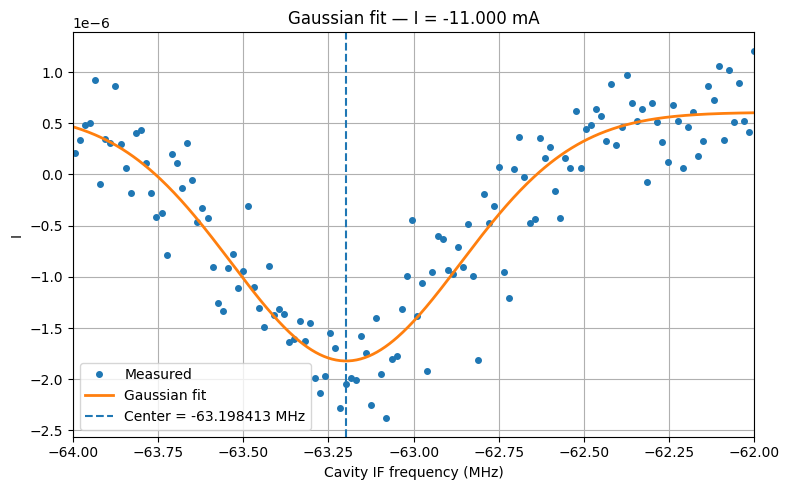

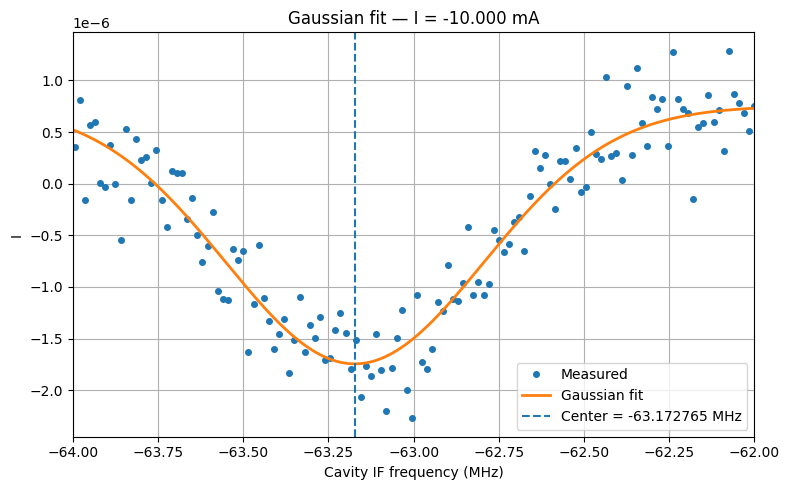

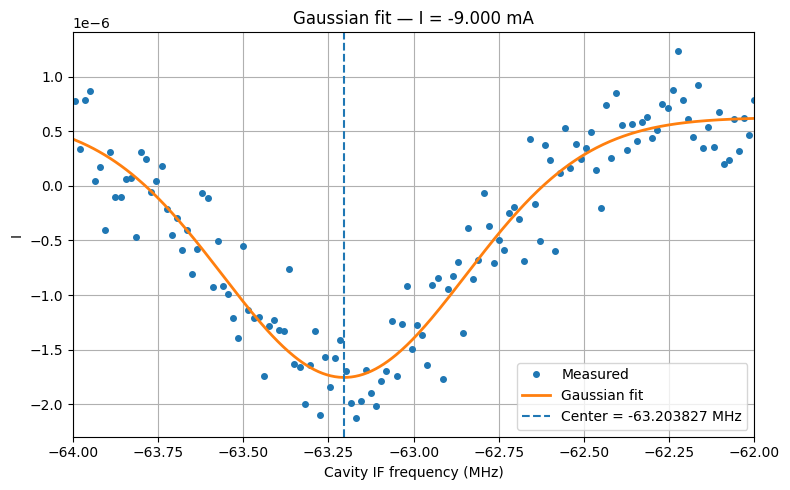

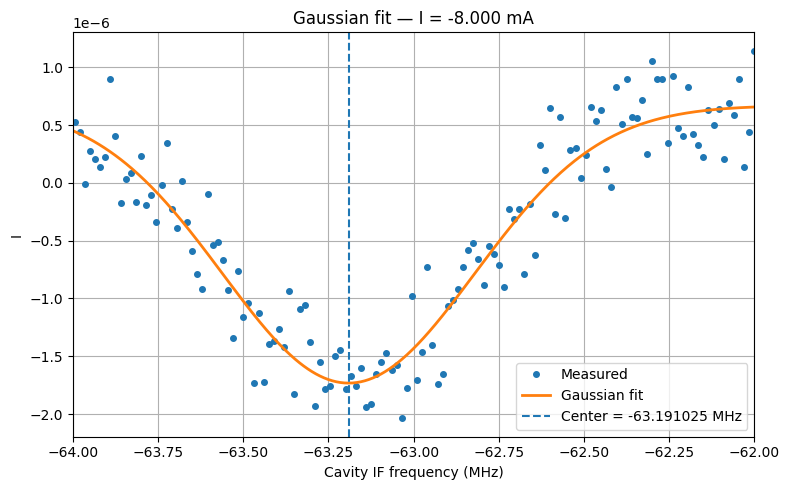

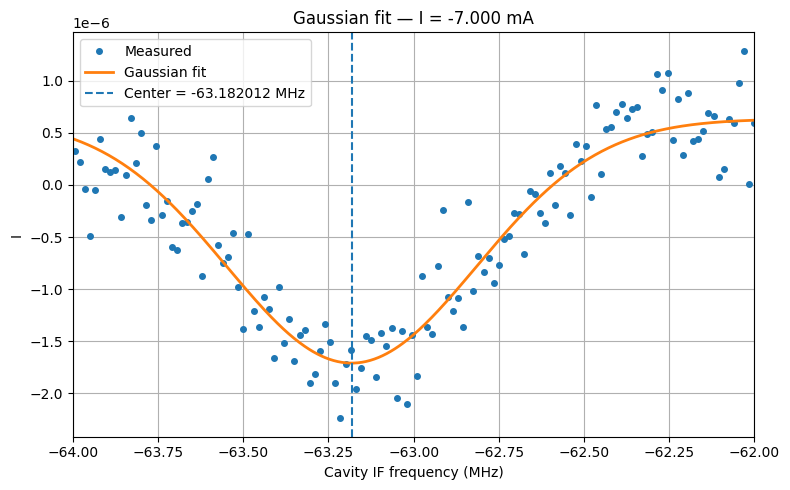

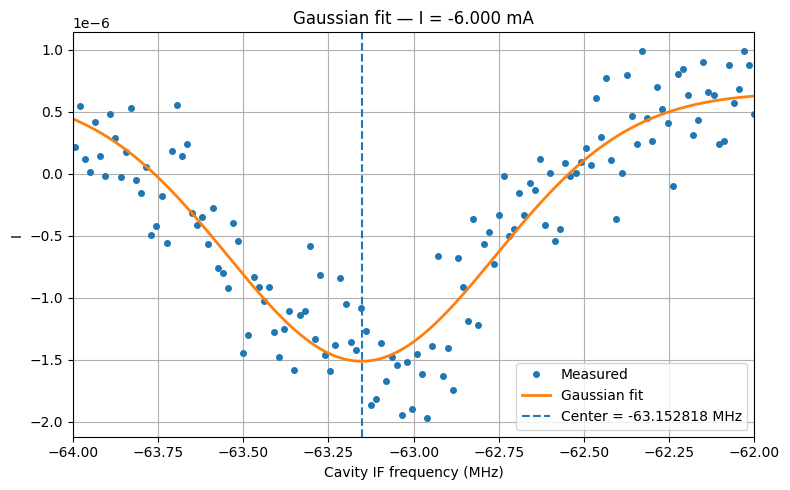

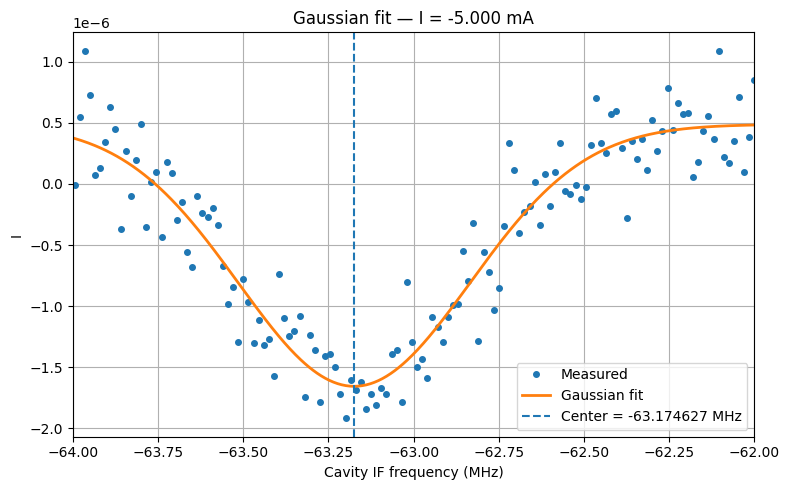

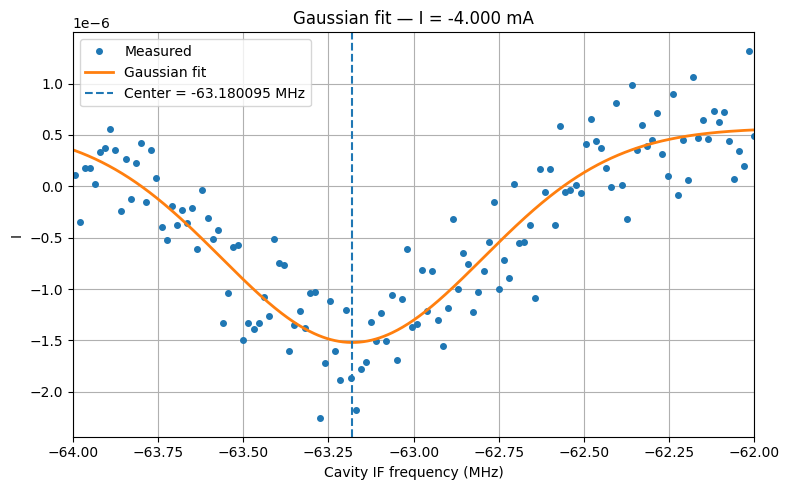

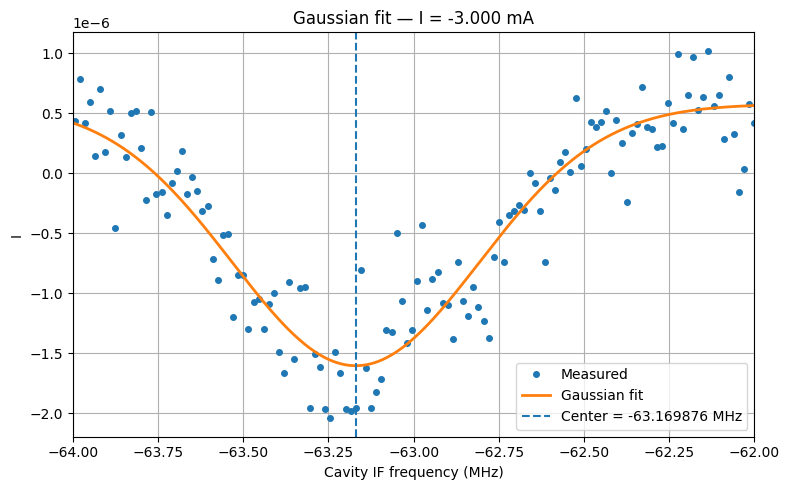

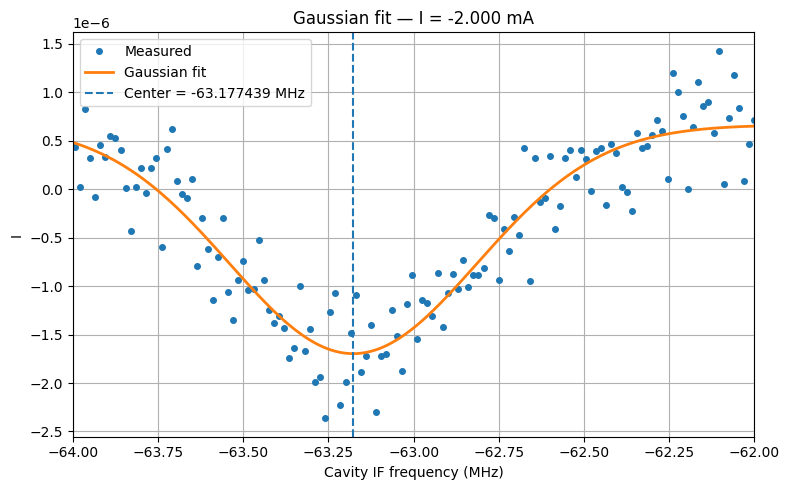

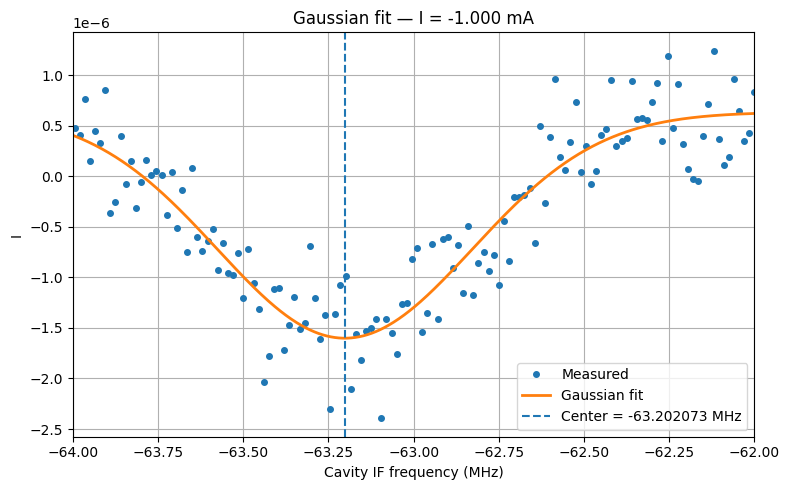

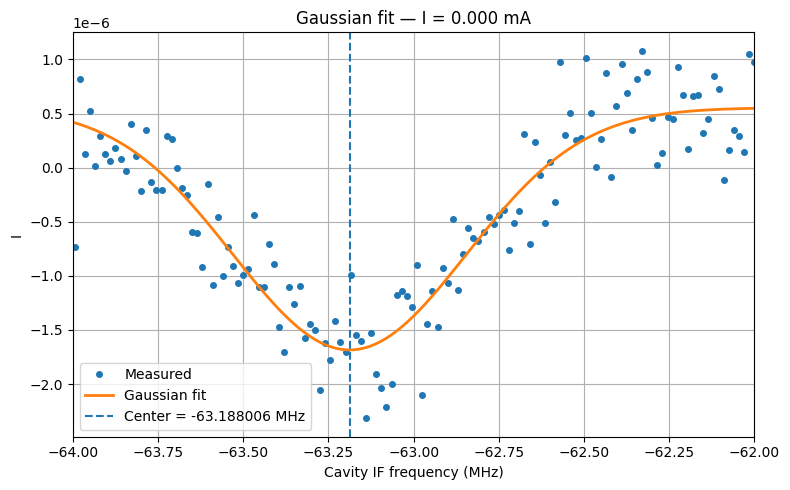

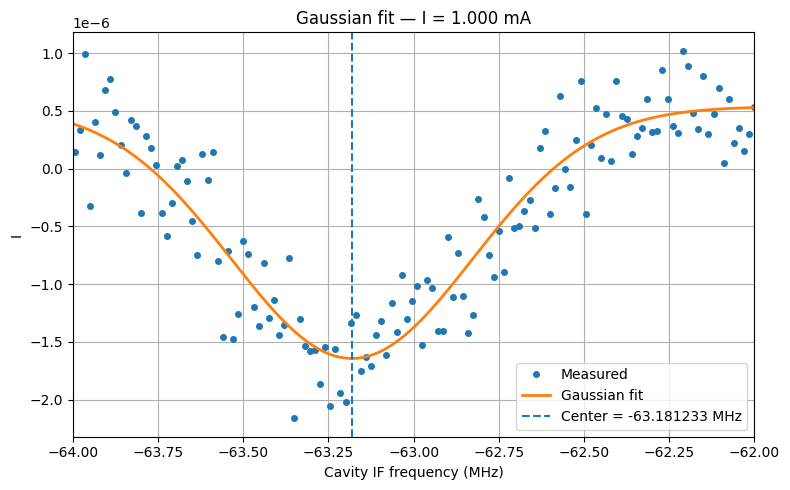

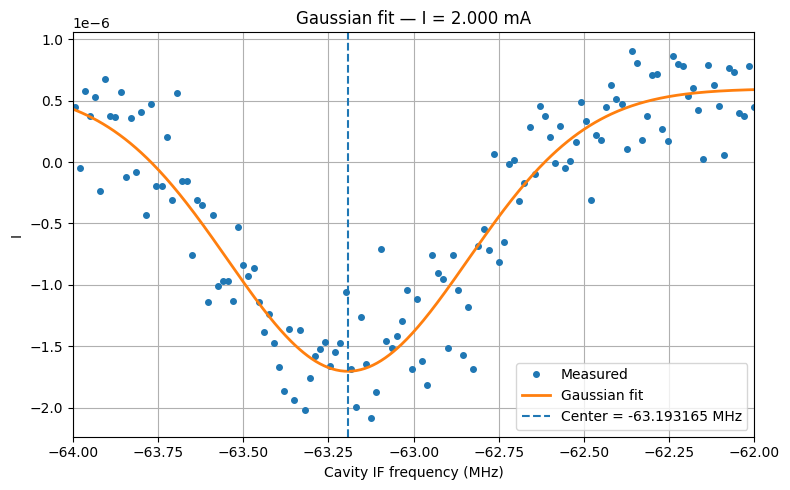

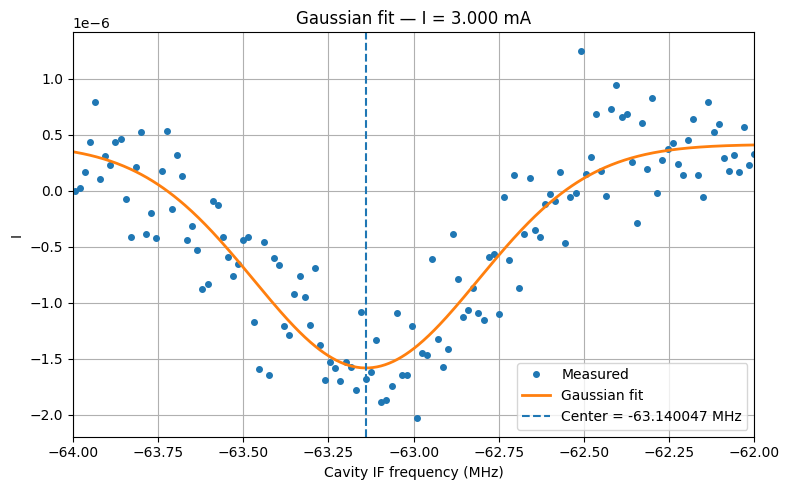

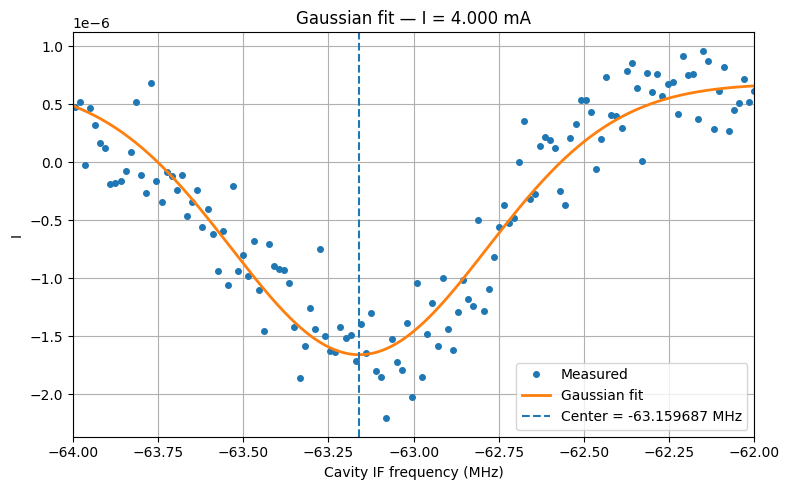

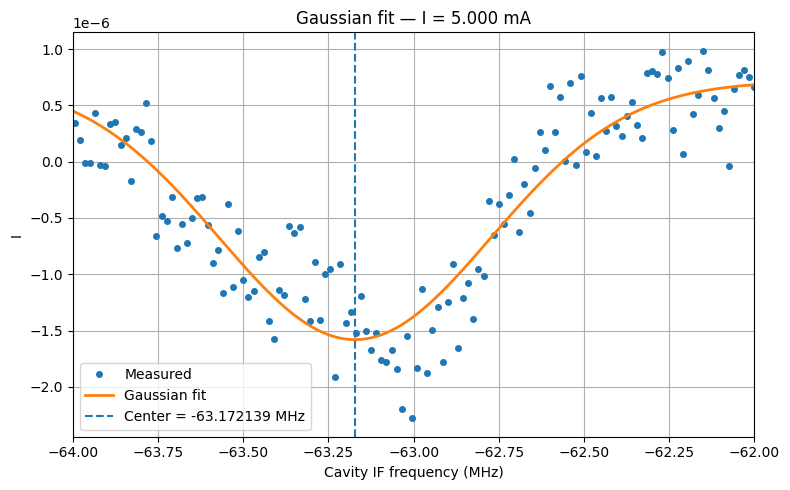

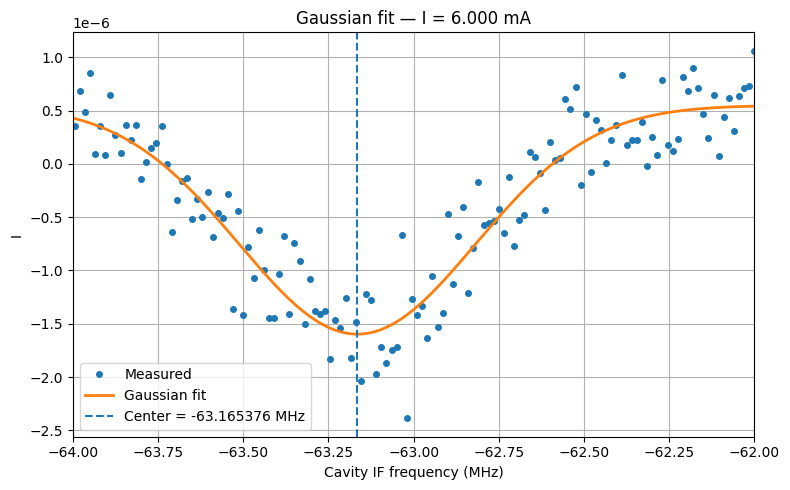

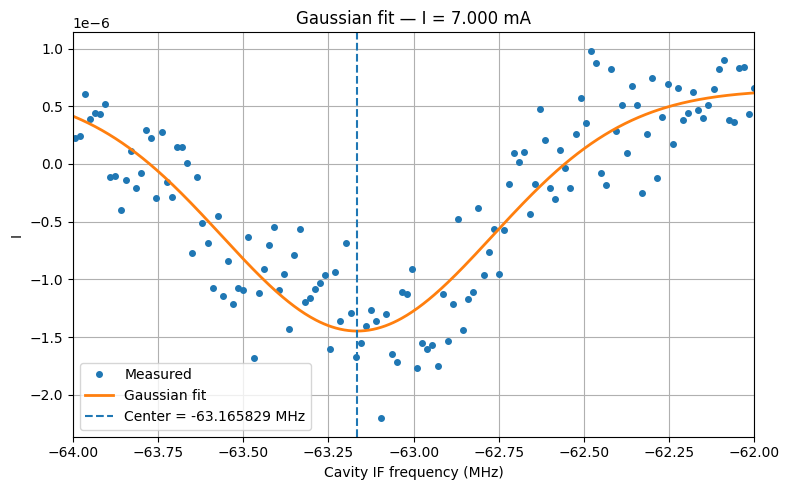

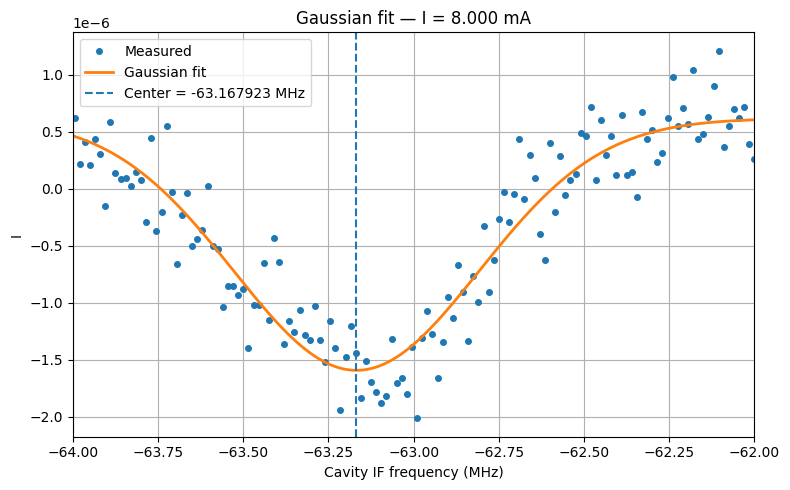

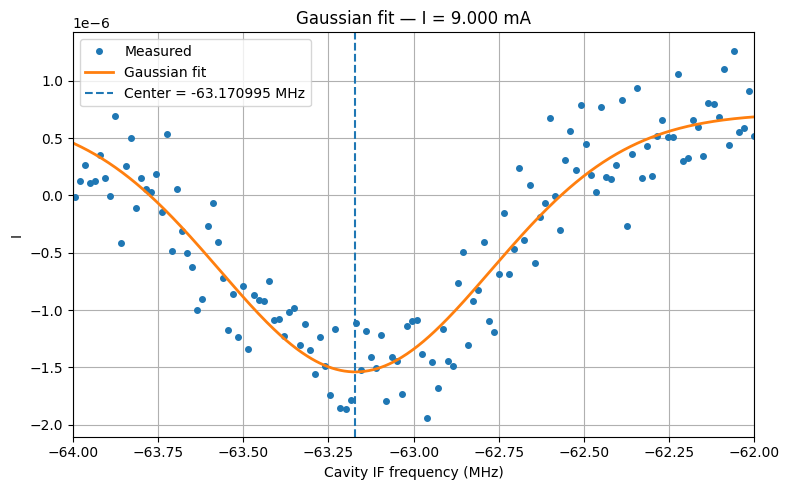

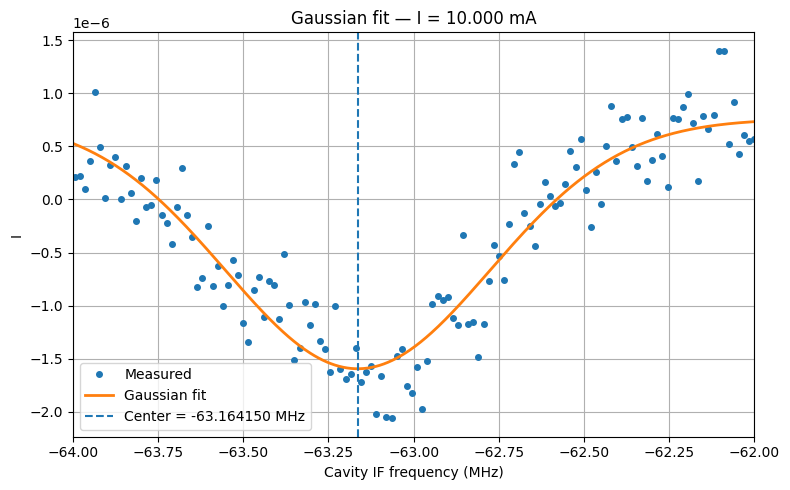

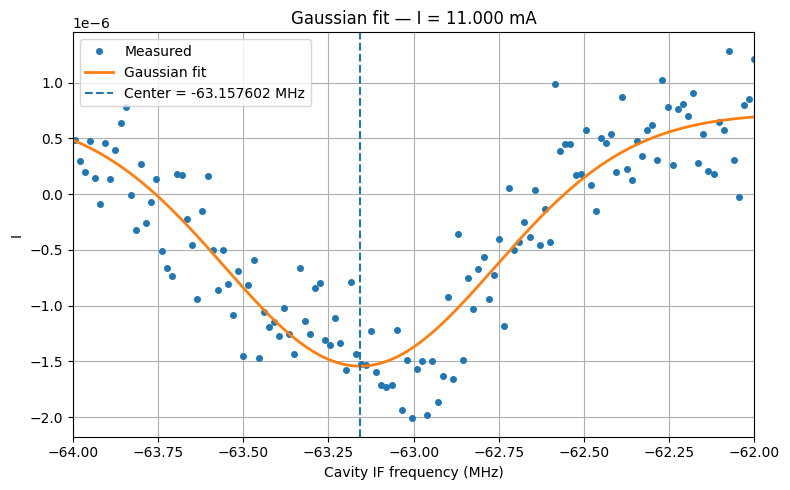

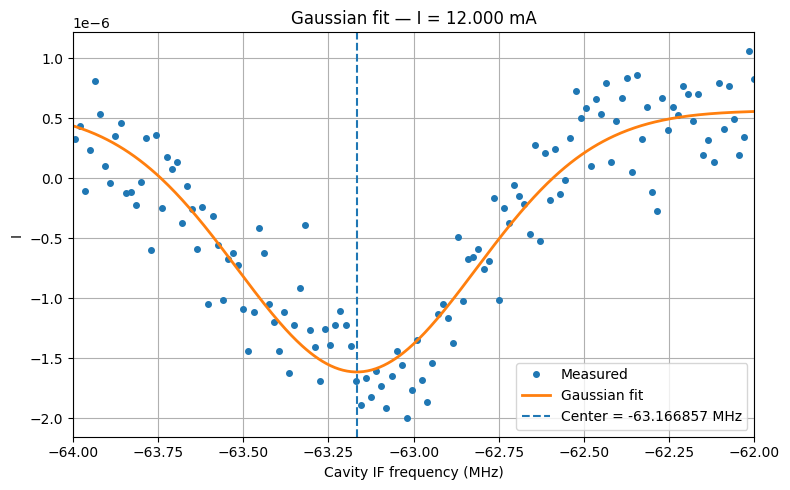

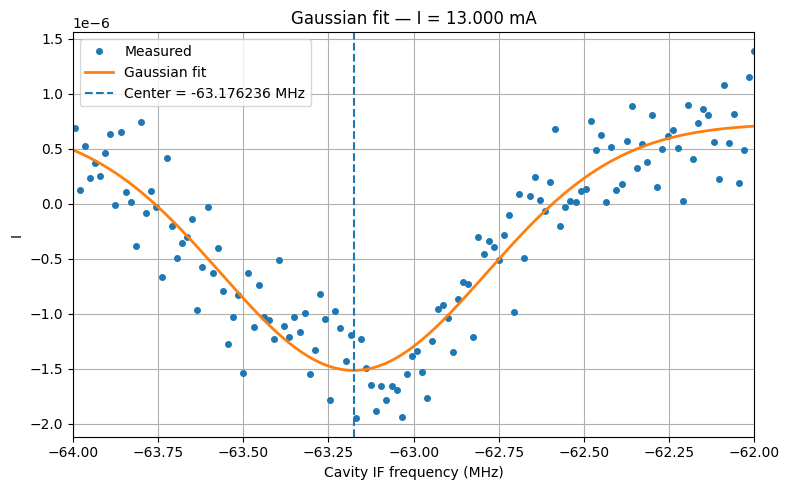

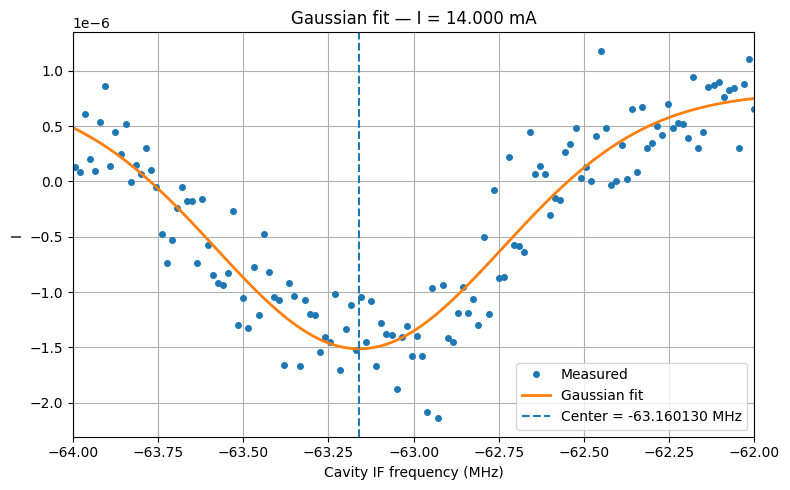

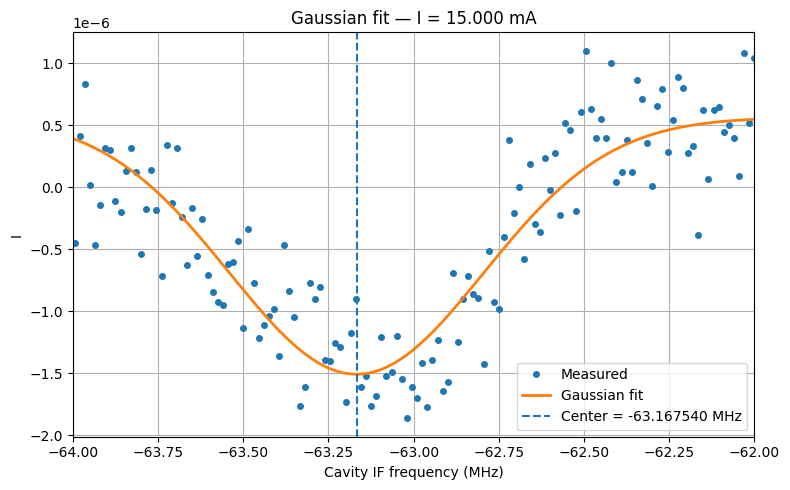

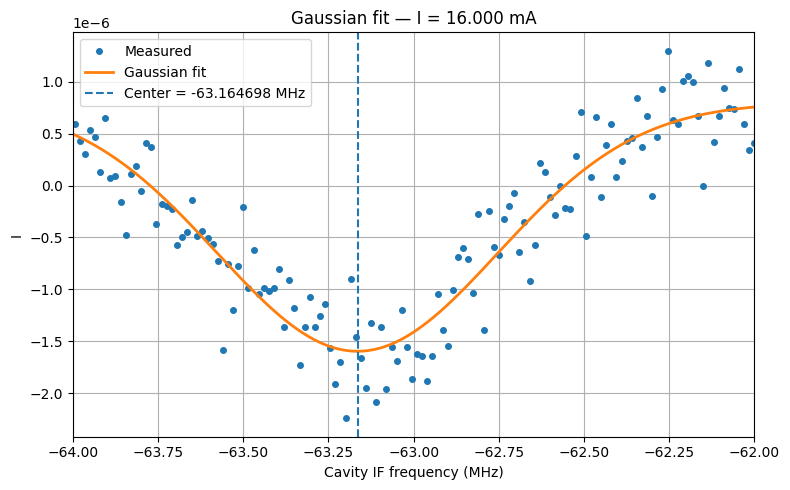

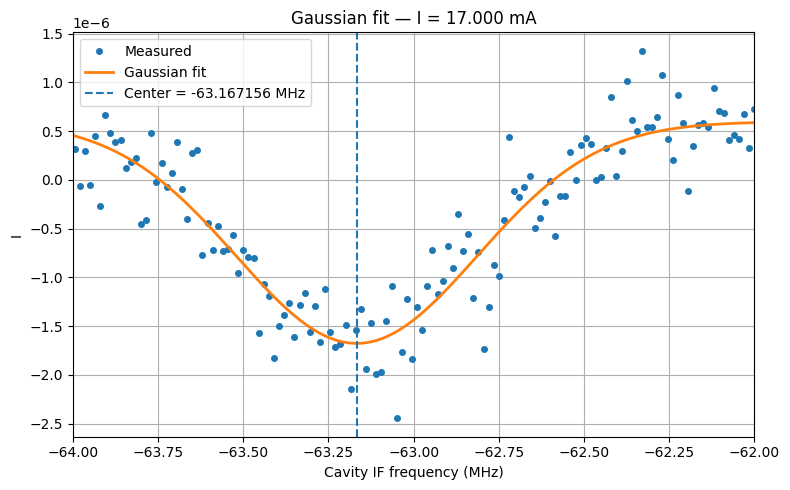

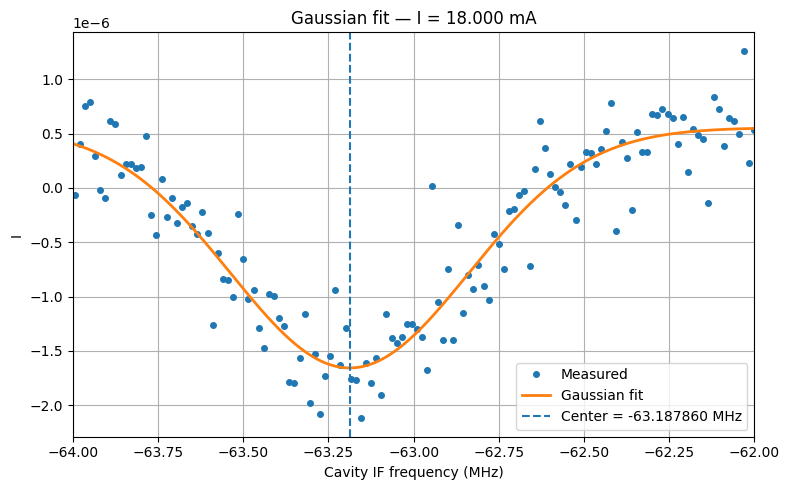

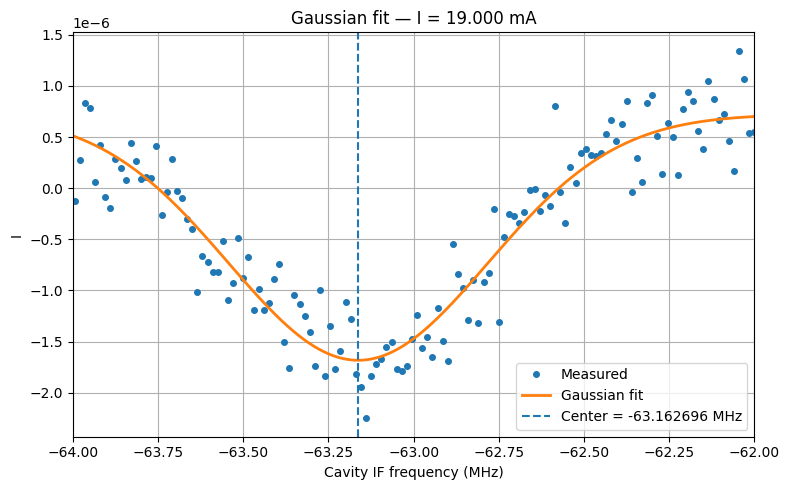

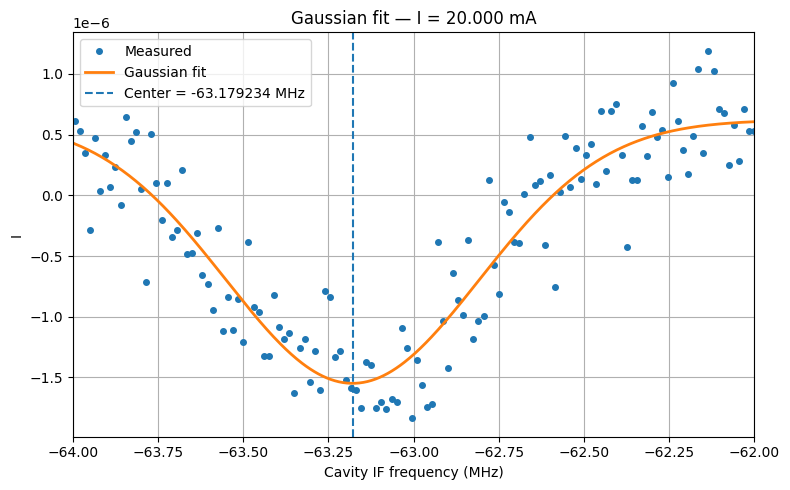

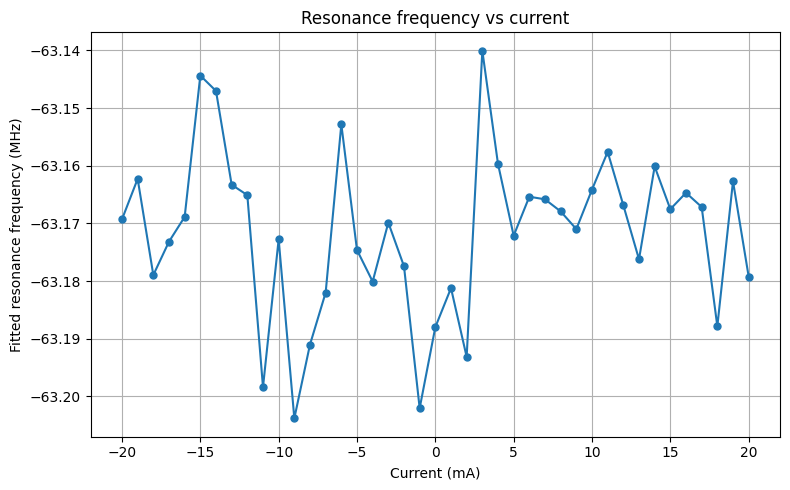

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    currents_mA = x_values * 1e3

    # ==========================================================
    # Gaussian function
    # ==========================================================
    def gaussian(x, amplitude, center, sigma, offset):
        return (
            offset
            + amplitude * np.exp(
                -(x - center)**2 / (2 * sigma**2)
            )
        )

    # ==========================================================
    # Store fitted resonance frequencies
    # ==========================================================
    fit_freq = []

    # ==========================================================
    # FIT EACH CURRENT SEPARATELY
    # ==========================================================
    for i, current in enumerate(currents_mA):

        x = y_values
        y = data_2d[i, :]

        # Fit range
        mask = (x >= -64e6) & (x <= -62e6)

        x_fit = x[mask]
        y_fit = y[mask]

        # Initial guesses
        center_guess = x_fit[np.argmin(y_fit)]
        offset_guess = np.max(y_fit)
        amplitude_guess = np.min(y_fit) - offset_guess
        sigma_guess = 0.2e6

        p0 = [
            amplitude_guess,
            center_guess,
            sigma_guess,
            offset_guess
        ]

        try:

            popt, pcov = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=p0,
                maxfev=10000
            )

            amplitude, center, sigma, offset = popt

            fit_freq.append(center)

            # ==================================================
            # Plot THIS CURRENT ONLY
            # ==================================================

            x_smooth = np.linspace(
                x_fit.min(),
                x_fit.max(),
                500
            )

            y_smooth = gaussian(
                x_smooth,
                *popt
            )

            plt.figure(figsize=(8, 5))

            # Measured data
            plt.plot(
                x_fit / 1e6,
                y_fit,
                "o",
                markersize=4,
                label="Measured"
            )

            # Gaussian fit
            plt.plot(
                x_smooth / 1e6,
                y_smooth,
                "-",
                linewidth=2,
                label="Gaussian fit"
            )

            # Fitted center
            plt.axvline(
                center / 1e6,
                linestyle="--",
                label=f"Center = {center/1e6:.6f} MHz"
            )

            plt.xlabel("Cavity IF frequency (MHz)")
            plt.ylabel(plot_data)

            plt.title(
                f"Gaussian fit — I = {current:.3f} mA"
            )

            plt.xlim(-64, -62)

            plt.grid(True)
            plt.legend()

            plt.tight_layout()
            plt.show()

        except RuntimeError:

            print(
                f"Fit failed at I = {current:.3f} mA"
            )

            fit_freq.append(np.nan)

    fit_freq = np.array(fit_freq)

    # ==========================================================
    # Resonance frequency vs current
    # ==========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        currents_mA,
        fit_freq / 1e6,
        "o-",
        markersize=5
    )

    plt.xlabel("Current (mA)")
    plt.ylabel("Fitted resonance frequency (MHz)")

    plt.title("Resonance frequency vs current")

    plt.grid(True)

    plt.tight_layout()
    plt.show()